## NicheJepa Model training

Creator: Mohammad Vali Sanian (mohammad.sanian@helsinki.fi) (mv10@sanger.ac.uk).

Date of Creation: 16.08.2024

Date of Last Modification: 17.08.2024

# 1. Setup

## 1.1 Libraries 

In [1]:
import torch
import os
import logging
import scanpy as sc
from sklearn.metrics.pairwise import cosine_similarity
from src.nichejepa.train import train
from src.nichejepa.eval import evaluation
from src.nichejepa.utils.config_utils import create_params_from_YAML_wandb_config, prepare_dataset
from src.nichejepa.utils.distributed import init_distributed
from src.nichejepa.utils.eval_utils import clustering_metrics, classification_metrics

#import nichejepa as nk
#print(dir(nk))
#print(nk.utils.get_ensembl_ids)

## 1.2 Create params

In [2]:
rank=0
logging.basicConfig()
logger = logging.getLogger()
logger.setLevel(logging.INFO if rank == 0 else logging.ERROR)
params = create_params_from_YAML_wandb_config('configs/cnd_gtb10_ep300.yaml',logger)

INFO:root:Loaded parameters from YAML file.


## 1.3 Create Train,Test dataset

In [3]:
train_dataset, test_dataset = prepare_dataset(params)

## 1.4 INIT distributed (it should change later)

In [4]:
devices=['cuda:0']
world_size=1
os.environ['CUDA_VISIBLE_DEVICES'] = str(devices[rank].split(':')[-1])

logging.basicConfig()
logger = logging.getLogger()
logger.setLevel(logging.INFO if rank == 0 else logging.ERROR)

world_size, rank = init_distributed(rank_and_world_size=(rank, world_size), port=40316)
logger.info(f'Running... (rank: {rank}/{world_size})')

INFO:root:Running... (rank: 0/1)


# 2.Model Training With just_cell and just_neighborhood as True

## 2.1 Train Model

In [6]:
params['data']['just_cell'] = True
params['data']['just_neighborhood'] = True
train(params, train_dataset, test_dataset)

INFO:root:Initialized (rank/world-size) 0/1
INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)
INFO:root

/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:[1,     0] loss: 0.520 masks: 305.0 20.0 [wd: 4.00e-02] [lr: 5.00e-05] [mem: 1.06e+04] (417.8 ms)
INFO:root:[1,     0] grad_stats: [8.17e-02 7.17e-02] (2.72e-04, 9.38e-02)
INFO:root:[1,    10] loss: 0.361 masks: 300.5 19.9 [wd: 4.00e-02] [lr: 4.95e-05] [mem: 1.10e+04] (248.5 ms)
INFO:root:[1,    10] grad_stats: [3.60e-03 3.91e-03] (1.39e-05, 4.58e-03)
INFO:root:[1,    20] loss: 0.332 masks: 301.1 19.9 [wd: 4.00e-02] [lr: 4.90e-05] [mem: 1.10e+04] (240.9 ms)
INFO:root:[1,    20] grad_stats: [1.99e-03 2.06e-03] (7.46e-06, 2.56e-03)
INFO:root:[1,    30] loss: 0.320 masks: 299.8 19.9 [wd: 4.01e-02] [lr: 4.85e-05] [mem: 1.10e+04] (237.0 ms)
INFO:root:[1,    30] grad_stats: [7.29e-04 7.39e-04] (3.61e-06, 8.70e-04)
INFO:root:[1,    40] loss: 0.314 masks: 299.3 19.9 [wd: 4.02e-02] [lr: 4.80e-05] [mem: 1.10e+04] (234.7 ms)
INFO:root:[1,    40] grad_stats: [1.53e-03 1.68e-03] (5.86e-06, 2.07e-03)
INFO:root:[1,    50] loss: 0.307 masks: 300.4 19.9 [wd: 4.03e-02] [lr: 4.75e-05] [mem: 1.1

# 3. Analysis With just_cell and just_neighborhood as True

## 3.1 Cell Type Average

In [7]:
params['emb']['retrieve_cell'] = True
params['emb']['retrieve_niche'] = False
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=False
params['emb']['average']=True
params['emb']['cls']=False
adata = evaluation(params, train_dataset, test_dataset)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0

200it [00:22,  8.78it/s]
50it [00:06,  7.28it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell_just_neighborhood/extracted_features/cell_embedding_average.h5ad


### 3.1.1 Feature Analysis

In [8]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[1.        , 0.99908894, 0.9992185 , ..., 0.9991702 , 0.9990417 ,
        0.99913555],
       [0.99908894, 1.0000001 , 0.99919844, ..., 0.9992112 , 0.9991579 ,
        0.9991498 ],
       [0.9992185 , 0.99919844, 1.0000001 , ..., 0.99924433, 0.99908817,
        0.99910545],
       ...,
       [0.9991702 , 0.9992112 , 0.99924433, ..., 0.9999999 , 0.9990957 ,
        0.9992855 ],
       [0.9990417 , 0.9991579 , 0.99908817, ..., 0.9990957 , 0.99999976,
        0.99896944],
       [0.99913555, 0.9991498 , 0.99910545, ..., 0.9992855 , 0.99896944,
        1.0000001 ]], dtype=float32)

### 3.1.2 Umap

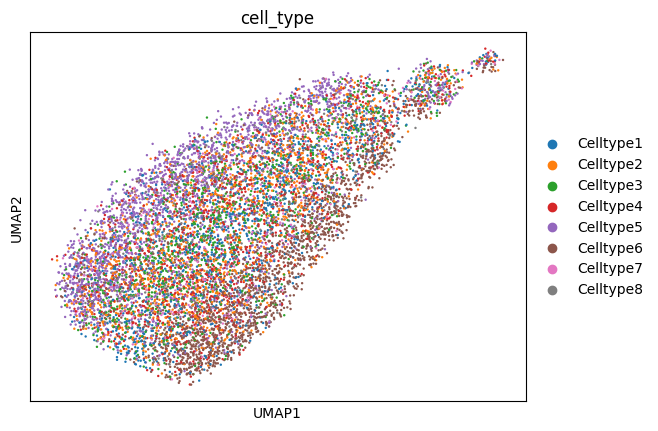

In [13]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')

### 3.1.3 Logistic regression

In [10]:
classification_metrics(adata, label_col='cell_type', classifier='logistic')

Test Accuracy: 0.74
Test F1 Score: 0.72
Train Accuracy: 0.77
Train F1 Score: 0.75


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'test_accuracy': 0.7385,
 'test_f1': 0.7182290944437199,
 'train_accuracy': 0.772875,
 'train_f1': 0.7543195784689671}

### 3.1.4 KNeighborsClassifier

In [14]:
classification_metrics(adata, label_col='cell_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.44
Test F1 Score: 0.36
Train Accuracy: 0.54
Train F1 Score: 0.48


{'test_accuracy': 0.4445,
 'test_f1': 0.3615213839881529,
 'train_accuracy': 0.541375,
 'train_f1': 0.4825885036308383}

### 3.1.5 nmi&ari

In [12]:
clustering_metrics(adata,label_col='cell_type')

INFO:jax._src.xla_bridge:Unable to initialize backend 'cuda': 
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
NMI (Normalized Mutual Information): 0.1626326677982283
ARI (Adjusted Rand Index): 0.09304481158328747


{'nmi': 0.1626326677982283, 'ari': 0.09304481158328747}

## 3.2 Cell Type CLS

In [16]:
params['emb']['retrieve_cell'] = True
params['emb']['retrieve_niche'] = False
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=False
params['emb']['average']=False
params['emb']['cls']=True
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  9.42it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  8.78it/s]
50it [00:07,  6.97it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell_just_neighborhood/extracted_features/cell_embedding_cls.h5ad


### 3.2.1 Feature Analysis

In [17]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[1.0000001 , 0.99998856, 0.99998224, ..., 0.9999517 , 0.9999356 ,
        0.99988633],
       [0.99998856, 0.9999997 , 0.9999776 , ..., 0.9999471 , 0.99994195,
        0.9998779 ],
       [0.99998224, 0.9999776 , 1.        , ..., 0.999972  , 0.9998891 ,
        0.99993   ],
       ...,
       [0.9999517 , 0.9999471 , 0.999972  , ..., 0.9999999 , 0.9998249 ,
        0.9999576 ],
       [0.9999356 , 0.99994195, 0.9998891 , ..., 0.9998249 , 1.        ,
        0.99968326],
       [0.99988633, 0.9998779 , 0.99993   , ..., 0.9999576 , 0.99968326,
        1.        ]], dtype=float32)

### 3.2.2 Umap

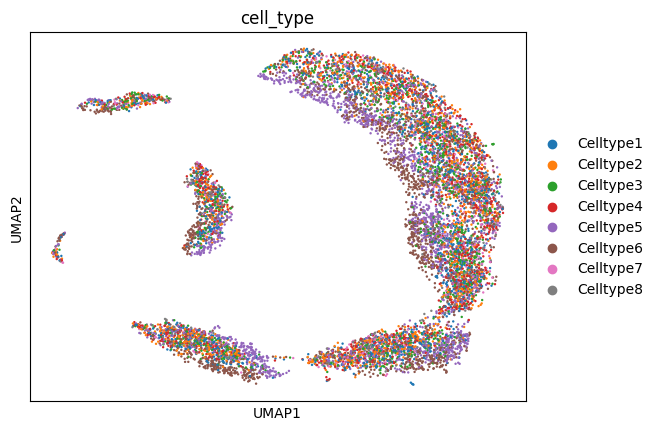

In [20]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')

### 3.2.3 Logistic regression

In [22]:
classification_metrics(adata, label_col='cell_type', classifier='logistic')

Test Accuracy: 0.38
Test F1 Score: 0.28
Train Accuracy: 0.37
Train F1 Score: 0.27


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'test_accuracy': 0.3795,
 'test_f1': 0.2828532175975031,
 'train_accuracy': 0.370625,
 'train_f1': 0.27464968066462087}

### 3.2.4 KNeighborsClassifier

In [23]:
classification_metrics(adata, label_col='cell_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.44
Test F1 Score: 0.44
Train Accuracy: 0.63
Train F1 Score: 0.62


{'test_accuracy': 0.442,
 'test_f1': 0.44329992024323167,
 'train_accuracy': 0.625125,
 'train_f1': 0.6204075074697325}

### 3.2.5 nmi&ari

In [24]:
clustering_metrics(adata,label_col='cell_type')

NMI (Normalized Mutual Information): 0.0020035980451704274
ARI (Adjusted Rand Index): 0.0006142269967747259


{'nmi': 0.0020035980451704274, 'ari': 0.0006142269967747259}

## 3.3 Cell Type weighted_average

In [25]:
params['emb']['retrieve_cell'] = True
params['emb']['retrieve_niche'] = False
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=True
params['emb']['average']=False
params['emb']['cls']=False
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  9.40it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  8.76it/s]
50it [00:06,  7.33it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell_just_neighborhood/extracted_features/cell_embedding_weighted_average.h5ad


### 3.3.1 Feature Analysis

In [26]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[1.0000002 , 0.99963707, 0.9995059 , ..., 0.9963757 , 0.99951833,
        0.9980506 ],
       [0.99963707, 0.9999998 , 0.99955964, ..., 0.99677086, 0.9994613 ,
        0.99831814],
       [0.9995059 , 0.99955964, 0.99999994, ..., 0.99767387, 0.99906147,
        0.9988424 ],
       ...,
       [0.9963757 , 0.99677086, 0.99767387, ..., 0.99999976, 0.99499214,
        0.9992374 ],
       [0.99951833, 0.9994613 , 0.99906147, ..., 0.99499214, 1.        ,
        0.99691284],
       [0.9980506 , 0.99831814, 0.9988424 , ..., 0.9992374 , 0.99691284,
        0.99999976]], dtype=float32)

### 3.3.2 Umap

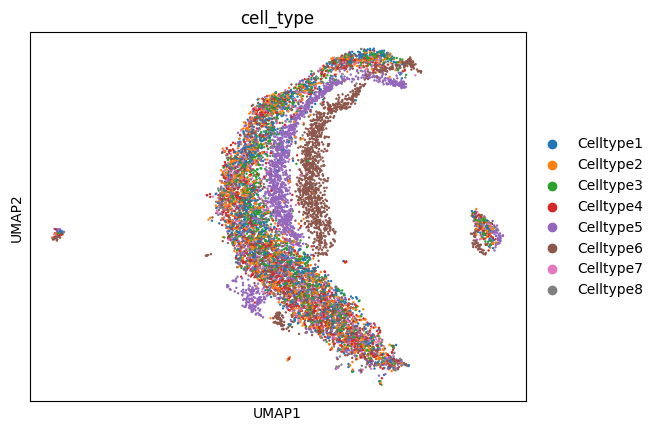

In [29]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')

### 3.3.3 Logistic regression

In [31]:
classification_metrics(adata, label_col='cell_type', classifier='logistic')

Test Accuracy: 0.61
Test F1 Score: 0.59
Train Accuracy: 0.60
Train F1 Score: 0.57


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'test_accuracy': 0.613,
 'test_f1': 0.5940301449602395,
 'train_accuracy': 0.595125,
 'train_f1': 0.5738124407778921}

### 3.3.4 KNN

In [34]:
classification_metrics(adata, label_col='cell_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.56
Test F1 Score: 0.55
Train Accuracy: 0.69
Train F1 Score: 0.68


{'test_accuracy': 0.558,
 'test_f1': 0.5500258289620659,
 'train_accuracy': 0.686375,
 'train_f1': 0.6801705072158614}

### 3.3.5 nmi&ari

In [35]:
clustering_metrics(adata,label_col='cell_type')

NMI (Normalized Mutual Information): 0.010370092976165615
ARI (Adjusted Rand Index): 0.004436298332424214


{'nmi': 0.010370092976165615, 'ari': 0.004436298332424214}

## 3.4 Niche Type Average

In [37]:
params['emb']['retrieve_cell'] = False
params['emb']['retrieve_niche'] = True
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=False
params['emb']['average']=True
params['emb']['cls']=False
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  9.41it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  8.76it/s]
50it [00:06,  7.45it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'niche_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell_just_neighborhood/extracted_features/niche_embedding_average.h5ad


### 3.4.1 Feature Analysis

In [39]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[0.99999976, 0.99990565, 0.99990094, ..., 0.99984103, 0.99988186,
        0.999767  ],
       [0.99990565, 0.9999999 , 0.9998848 , ..., 0.9998231 , 0.99987924,
        0.99974847],
       [0.99990094, 0.9998848 , 1.        , ..., 0.9998392 , 0.99982405,
        0.9997621 ],
       ...,
       [0.99984103, 0.9998231 , 0.9998392 , ..., 1.0000002 , 0.9997302 ,
        0.99979293],
       [0.99988186, 0.99987924, 0.99982405, ..., 0.9997302 , 0.9999999 ,
        0.99957204],
       [0.999767  , 0.99974847, 0.9997621 , ..., 0.99979293, 0.99957204,
        1.        ]], dtype=float32)

### 3.4.2 Umap

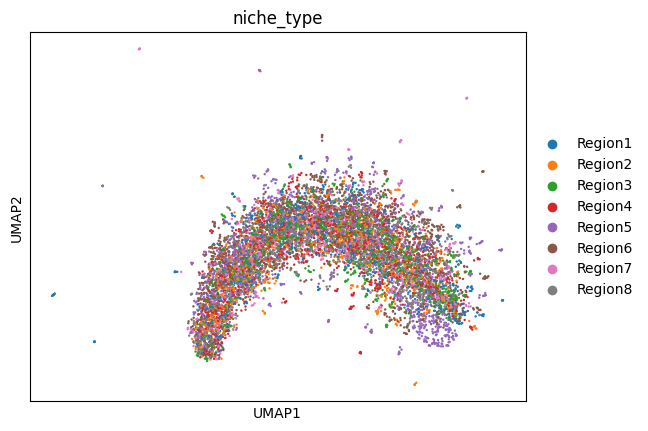

In [41]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='niche_type')

### 3.4.3 Logistic regression

In [43]:
classification_metrics(adata, label_col='niche_type', classifier='logistic')

Test Accuracy: 0.56
Test F1 Score: 0.53
Train Accuracy: 0.58
Train F1 Score: 0.55


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'test_accuracy': 0.558,
 'test_f1': 0.5264804626314896,
 'train_accuracy': 0.58225,
 'train_f1': 0.5515243259321804}

### 3.4.4 KNN

In [45]:
classification_metrics(adata, label_col='niche_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.78
Test F1 Score: 0.78
Train Accuracy: 0.90
Train F1 Score: 0.90


{'test_accuracy': 0.776,
 'test_f1': 0.7787168281997033,
 'train_accuracy': 0.90225,
 'train_f1': 0.9026767027648281}

### 3.4.5 nmi&ari

In [46]:
clustering_metrics(adata,label_col='niche_type')

NMI (Normalized Mutual Information): 0.00926670775412232
ARI (Adjusted Rand Index): 0.0033595531792556138


{'nmi': 0.00926670775412232, 'ari': 0.0033595531792556138}

## 3.5 Niche Type CLS

In [48]:
params['emb']['retrieve_cell'] = False
params['emb']['retrieve_niche'] = True
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=False
params['emb']['average']=False
params['emb']['cls']=True
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  9.40it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  8.82it/s]
50it [00:06,  7.64it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'niche_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell_just_neighborhood/extracted_features/niche_embedding_cls.h5ad


### 3.5.1 Feature Analysis

In [49]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[1.0000001 , 0.99998856, 0.99998224, ..., 0.9999517 , 0.9999356 ,
        0.99988633],
       [0.99998856, 0.9999997 , 0.9999776 , ..., 0.9999471 , 0.99994195,
        0.9998779 ],
       [0.99998224, 0.9999776 , 1.        , ..., 0.999972  , 0.9998891 ,
        0.99993   ],
       ...,
       [0.9999517 , 0.9999471 , 0.999972  , ..., 0.9999999 , 0.9998249 ,
        0.9999576 ],
       [0.9999356 , 0.99994195, 0.9998891 , ..., 0.9998249 , 1.        ,
        0.99968326],
       [0.99988633, 0.9998779 , 0.99993   , ..., 0.9999576 , 0.99968326,
        1.        ]], dtype=float32)

### 3.5.2 Umap

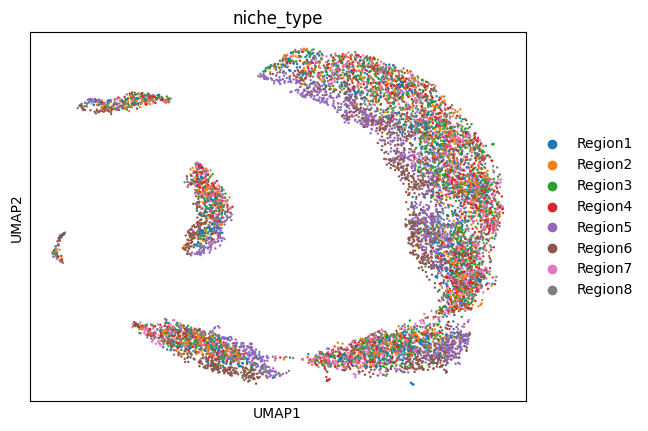

In [51]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='niche_type')

### 3.5.3 Logistic regression

In [52]:
classification_metrics(adata, label_col='niche_type', classifier='logistic')

Test Accuracy: 0.39
Test F1 Score: 0.30
Train Accuracy: 0.40
Train F1 Score: 0.30


{'test_accuracy': 0.3945,
 'test_f1': 0.3019261709653612,
 'train_accuracy': 0.399,
 'train_f1': 0.30083662493159796}

### 3.5.4 KNN

In [54]:
classification_metrics(adata, label_col='niche_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.55
Test F1 Score: 0.54
Train Accuracy: 0.76
Train F1 Score: 0.76


{'test_accuracy': 0.5465,
 'test_f1': 0.5420356834332786,
 'train_accuracy': 0.75925,
 'train_f1': 0.7571679473564188}

### 3.5.5 nmi&ari

In [55]:
clustering_metrics(adata,label_col='niche_type')

NMI (Normalized Mutual Information): 0.0031044183814429895
ARI (Adjusted Rand Index): 0.001518930901713043


{'nmi': 0.0031044183814429895, 'ari': 0.001518930901713043}

## 3.6 Niche Type weighted_average

In [56]:
params['emb']['retrieve_cell'] = False
params['emb']['retrieve_niche'] = True
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=True
params['emb']['average']=False
params['emb']['cls']=False
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  9.40it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:22,  8.71it/s]
50it [00:06,  7.61it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'niche_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell_just_neighborhood/extracted_features/niche_embedding_weighted_average.h5ad


### 3.6.1 Feature Analysis

In [57]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[1.0000002 , 0.99963707, 0.9995059 , ..., 0.9963757 , 0.99951833,
        0.9980506 ],
       [0.99963707, 0.9999998 , 0.99955964, ..., 0.99677086, 0.9994613 ,
        0.99831814],
       [0.9995059 , 0.99955964, 0.99999994, ..., 0.99767387, 0.99906147,
        0.9988424 ],
       ...,
       [0.9963757 , 0.99677086, 0.99767387, ..., 0.99999976, 0.99499214,
        0.9992374 ],
       [0.99951833, 0.9994613 , 0.99906147, ..., 0.99499214, 1.        ,
        0.99691284],
       [0.9980506 , 0.99831814, 0.9988424 , ..., 0.9992374 , 0.99691284,
        0.99999976]], dtype=float32)

### 3.6.2 Umap

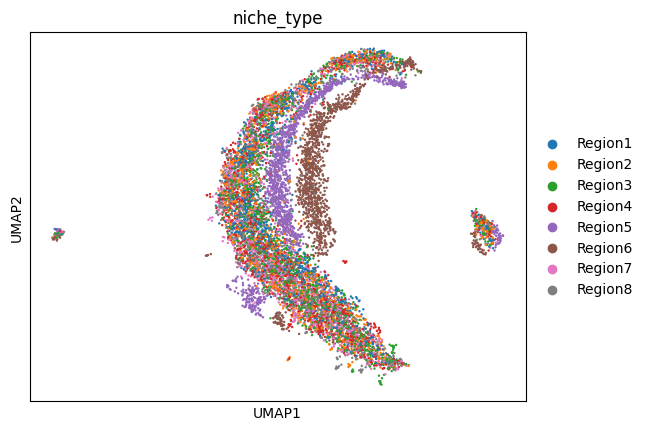

In [60]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='niche_type')

### 3.6.3 Logistic regression

In [62]:
classification_metrics(adata, label_col='niche_type', classifier='logistic')

Test Accuracy: 0.71
Test F1 Score: 0.70
Train Accuracy: 0.75
Train F1 Score: 0.73


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'test_accuracy': 0.715,
 'test_f1': 0.6967229404262123,
 'train_accuracy': 0.7475,
 'train_f1': 0.7304414673295996}

### 3.6.4 KNN

In [63]:
classification_metrics(adata, label_col='niche_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.74
Test F1 Score: 0.73
Train Accuracy: 0.87
Train F1 Score: 0.86


{'test_accuracy': 0.74,
 'test_f1': 0.7300058089696055,
 'train_accuracy': 0.866,
 'train_f1': 0.8636938237361864}

### 3.6.5 nmi&ari

In [65]:
clustering_metrics(adata,label_col='niche_type')

NMI (Normalized Mutual Information): 0.032668911490466995
ARI (Adjusted Rand Index): 0.01622052432938741


{'nmi': 0.032668911490466995, 'ari': 0.01622052432938741}

## 3.7 Retrieve Gene

In [68]:
params['emb']['retrieve_cell'] = False
params['emb']['retrieve_niche'] = False
params['emb']['retrieve_gene'] = True
params['emb']['weighted_average']=False
params['emb']['average']=True
params['emb']['cls']=False
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)
INFO:root:loaded pretrained encoder from epoch 15 wit

200it [00:22,  8.74it/s]
50it [00:06,  7.34it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell_just_neighborhood/extracted_features/gene_embedding_gene_id_332_average.h5ad


### 3.7.1 Feature Analysis

In [69]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 1.0000001, ..., 0.       , 0.       ,
        0.9999306],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.9999306, ..., 0.       , 0.       ,
        1.0000001]], dtype=float32)

### 3.7.2 Umap

In [73]:
adata = adata[adata.obs['gene_count']!=0]

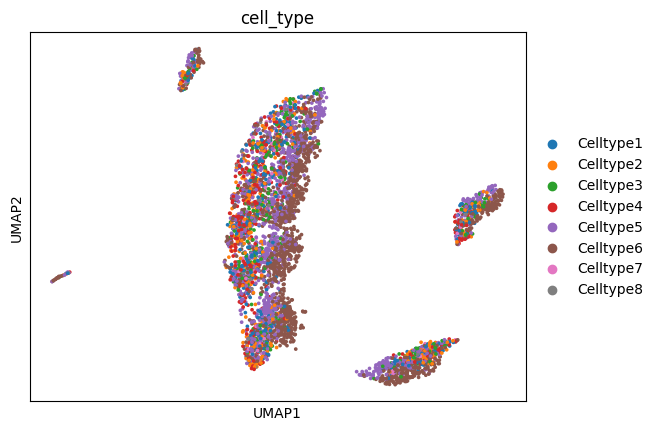

In [74]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')

# 4.Model Training With just_cell as True

## 4.1 Train Model

In [77]:
params['data']['just_cell'] = True
params['data']['just_neighborhood'] = False
train(params, train_dataset, test_dataset)

INFO:root:Initialized (rank/world-size) 0/1
INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)
INFO:root

/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


INFO:root:[1,     0] loss: 0.517 masks: 285.0 20.0 [wd: 4.00e-02] [lr: 5.00e-05] [mem: 1.17e+04] (164.2 ms)
INFO:root:[1,     0] grad_stats: [1.62e-01 1.34e-01] (3.43e-04, 1.89e-01)
INFO:root:[1,    10] loss: 0.322 masks: 285.0 19.5 [wd: 4.00e-02] [lr: 4.95e-05] [mem: 1.17e+04] (129.7 ms)
INFO:root:[1,    10] grad_stats: [5.27e-03 4.88e-03] (1.18e-05, 6.23e-03)
INFO:root:[1,    20] loss: 0.280 masks: 285.0 19.5 [wd: 4.00e-02] [lr: 4.90e-05] [mem: 1.17e+04] (127.8 ms)
INFO:root:[1,    20] grad_stats: [1.57e-03 1.57e-03] (3.84e-06, 1.98e-03)
INFO:root:[1,    30] loss: 0.260 masks: 285.0 19.5 [wd: 4.01e-02] [lr: 4.85e-05] [mem: 1.17e+04] (127.3 ms)
INFO:root:[1,    30] grad_stats: [6.57e-04 6.80e-04] (1.89e-06, 8.09e-04)
INFO:root:[1,    40] loss: 0.249 masks: 285.0 19.6 [wd: 4.02e-02] [lr: 4.80e-05] [mem: 1.17e+04] (127.2 ms)
INFO:root:[1,    40] grad_stats: [4.80e-04 4.95e-04] (1.56e-06, 6.09e-04)
INFO:root:[1,    50] loss: 0.242 masks: 285.0 19.6 [wd: 4.03e-02] [lr: 4.75e-05] [mem: 1.1

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


INFO:root:avg. loss 0.214
INFO:root:Epoch 2
INFO:root:[2,     0] loss: 0.195 masks: 285.0 20.0 [wd: 4.40e-02] [lr: 4.02e-05] [mem: 1.17e+04] (150.6 ms)
INFO:root:[2,     0] grad_stats: [5.06e-04 5.40e-04] (1.60e-06, 6.50e-04)
INFO:root:[2,    10] loss: 0.194 masks: 285.0 19.4 [wd: 4.44e-02] [lr: 3.97e-05] [mem: 1.17e+04] (127.9 ms)
INFO:root:[2,    10] grad_stats: [5.12e-04 4.96e-04] (1.60e-06, 6.34e-04)
INFO:root:[2,    20] loss: 0.194 masks: 285.0 19.5 [wd: 4.48e-02] [lr: 3.92e-05] [mem: 1.17e+04] (127.7 ms)
INFO:root:[2,    20] grad_stats: [4.94e-04 4.83e-04] (1.58e-06, 6.06e-04)
INFO:root:[2,    30] loss: 0.194 masks: 285.0 19.6 [wd: 4.52e-02] [lr: 3.87e-05] [mem: 1.17e+04] (127.7 ms)
INFO:root:[2,    30] grad_stats: [4.36e-04 4.69e-04] (1.49e-06, 5.70e-04)
INFO:root:[2,    40] loss: 0.193 masks: 285.0 19.6 [wd: 4.57e-02] [lr: 3.82e-05] [mem: 1.17e+04] (127.3 ms)
INFO:root:[2,    40] grad_stats: [4.67e-04 4.68e-04] (1.56e-06, 6.16e-04)
INFO:root:[2,    50] loss: 0.193 masks: 285.0 

# 5. Analysis With just_cell as True

## 5.1 Cell Type Average

In [80]:
params['emb']['retrieve_cell'] = True
params['emb']['retrieve_niche'] = False
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=False
params['emb']['average']=True
params['emb']['cls']=False
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)
INFO:root:loaded pretrained encoder from epoch 15 wit

200it [00:08, 24.15it/s]
50it [00:02, 20.60it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell/extracted_features/cell_embedding_average.h5ad


### 5.1.1 Feature Analysis

In [82]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[0.9999999 , 0.99894667, 0.99896276, ..., 0.99897254, 0.9990517 ,
        0.9991099 ],
       [0.99894667, 0.9999999 , 0.9990733 , ..., 0.99896276, 0.998976  ,
        0.9990001 ],
       [0.99896276, 0.9990733 , 1.0000002 , ..., 0.9989042 , 0.99902797,
        0.9990583 ],
       ...,
       [0.99897254, 0.99896276, 0.9989042 , ..., 1.0000001 , 0.9991189 ,
        0.99900097],
       [0.9990517 , 0.998976  , 0.99902797, ..., 0.9991189 , 1.0000001 ,
        0.9990396 ],
       [0.9991099 , 0.9990001 , 0.9990583 , ..., 0.99900097, 0.9990396 ,
        1.        ]], dtype=float32)

### 5.1.2 Umap

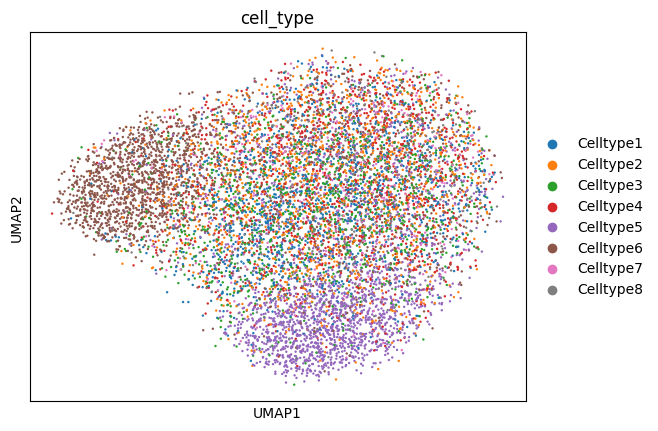

In [84]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')

### 5.1.3 Logistic regression

In [85]:
classification_metrics(adata, label_col='cell_type', classifier='logistic')

Test Accuracy: 0.74
Test F1 Score: 0.73
Train Accuracy: 0.80
Train F1 Score: 0.80


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'test_accuracy': 0.7445,
 'test_f1': 0.7309151894742649,
 'train_accuracy': 0.804,
 'train_f1': 0.7957384527799632}

### 5.1.4 KNN

In [88]:
classification_metrics(adata, label_col='cell_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.47
Test F1 Score: 0.43
Train Accuracy: 0.63
Train F1 Score: 0.60


{'test_accuracy': 0.472,
 'test_f1': 0.43022902196556395,
 'train_accuracy': 0.626,
 'train_f1': 0.60167892467917}

### 5.1.5 nmi&ari

In [89]:
clustering_metrics(adata,label_col='cell_type')

NMI (Normalized Mutual Information): 0.2958924037136388
ARI (Adjusted Rand Index): 0.2690808144333281


{'nmi': 0.2958924037136388, 'ari': 0.2690808144333281}

## 5.2 Cell Type CLS

In [92]:
params['emb']['retrieve_cell'] = True
params['emb']['retrieve_niche'] = False
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=False
params['emb']['average']=False
params['emb']['cls']=True
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
198it [00:08, 51.35it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:08, 23.91it/s]
50it [00:03, 15.75it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell/extracted_features/cell_embedding_cls.h5ad


### 5.2.1 Feature Analysis

In [94]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[0.99999976, 0.99992913, 0.9999323 , ..., 0.9997903 , 0.99991965,
        0.9999374 ],
       [0.99992913, 1.        , 0.9999383 , ..., 0.9998118 , 0.9999183 ,
        0.9999336 ],
       [0.9999323 , 0.9999383 , 1.0000001 , ..., 0.99980426, 0.9999243 ,
        0.99993014],
       ...,
       [0.9997903 , 0.9998118 , 0.99980426, ..., 1.        , 0.99984944,
        0.9997747 ],
       [0.99991965, 0.9999183 , 0.9999243 , ..., 0.99984944, 1.0000001 ,
        0.9999161 ],
       [0.9999374 , 0.9999336 , 0.99993014, ..., 0.9997747 , 0.9999161 ,
        1.0000002 ]], dtype=float32)

### 5.2.2 Umap

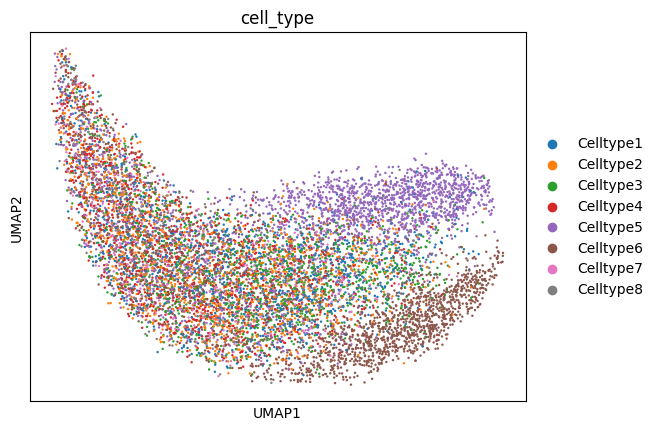

In [95]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')

### 5.2.3 Logistic regression

In [97]:
classification_metrics(adata, label_col='cell_type', classifier='logistic')

Test Accuracy: 0.56
Test F1 Score: 0.54
Train Accuracy: 0.57
Train F1 Score: 0.54


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'test_accuracy': 0.5625,
 'test_f1': 0.5378799009483246,
 'train_accuracy': 0.565375,
 'train_f1': 0.5401667013700944}

### 5.2.4 KNN

In [98]:
classification_metrics(adata, label_col='cell_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.47
Test F1 Score: 0.46
Train Accuracy: 0.63
Train F1 Score: 0.62


{'test_accuracy': 0.4685,
 'test_f1': 0.45663505227284923,
 'train_accuracy': 0.63325,
 'train_f1': 0.6242411848934095}

### 5.2.5 nmi&ari

In [100]:
clustering_metrics(adata,label_col='cell_type')

NMI (Normalized Mutual Information): 0.13065057097581786
ARI (Adjusted Rand Index): 0.05831974643799987


{'nmi': 0.13065057097581786, 'ari': 0.05831974643799987}

## 5.3 Cell Type weighted_average

In [102]:
params['emb']['retrieve_cell'] = True
params['emb']['retrieve_niche'] = False
params['emb']['retrieve_gene'] = False
params['emb']['weighted_average']=True
params['emb']['average']=False
params['emb']['cls']=False
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>
['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
INFO:root:loaded pretrained encoder from epoch 15 with msg: <All keys matched successfully>


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
199it [00:07, 54.32it/s]/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
200it [00:07, 27.23it/s]
50it [00:02, 22.57it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell/extracted_features/cell_embedding_weighted_average.h5ad


### 5.3.1 Feature Analysis

In [103]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[0.9999995 , 0.9986321 , 0.9985087 , ..., 0.99866605, 0.9986627 ,
        0.9987391 ],
       [0.9986321 , 1.0000004 , 0.99867916, ..., 0.99869144, 0.9985571 ,
        0.9986656 ],
       [0.9985087 , 0.99867916, 0.99999976, ..., 0.99858737, 0.99875623,
        0.99868184],
       ...,
       [0.99866605, 0.99869144, 0.99858737, ..., 1.0000002 , 0.99885374,
        0.99866986],
       [0.9986627 , 0.9985571 , 0.99875623, ..., 0.99885374, 0.9999999 ,
        0.9986286 ],
       [0.9987391 , 0.9986656 , 0.99868184, ..., 0.99866986, 0.9986286 ,
        0.99999976]], dtype=float32)

### 5.3.2 Umap

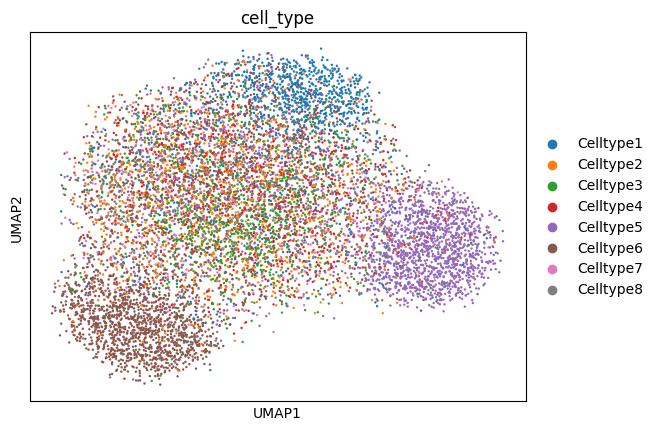

In [105]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')

### 5.3.3 Logistic regression

In [106]:
classification_metrics(adata, label_col='cell_type', classifier='logistic')

Test Accuracy: 0.83
Test F1 Score: 0.83
Train Accuracy: 0.90
Train F1 Score: 0.89


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'test_accuracy': 0.835,
 'test_f1': 0.830036948477027,
 'train_accuracy': 0.896875,
 'train_f1': 0.894882541576676}

### 5.3.4 KNN

In [107]:
classification_metrics(adata, label_col='cell_type', classifier='knn', n_neighbors=5)

Test Accuracy: 0.58
Test F1 Score: 0.54
Train Accuracy: 0.70
Train F1 Score: 0.68


{'test_accuracy': 0.576,
 'test_f1': 0.5442666057094581,
 'train_accuracy': 0.702625,
 'train_f1': 0.6847870009317844}

### 5.3.5 nmi&ari

In [109]:
clustering_metrics(adata,label_col='cell_type')

NMI (Normalized Mutual Information): 0.40504110340285565
ARI (Adjusted Rand Index): 0.21263970394926296


{'nmi': 0.40504110340285565, 'ari': 0.21263970394926296}

## 5.4 Retrieve Gene

In [111]:
params['emb']['retrieve_cell'] = False
params['emb']['retrieve_niche'] = False
params['emb']['retrieve_gene'] = True
params['emb']['weighted_average']=False
params['emb']['average']=True
params['emb']['cls']=False
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1108, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)
INFO:root:loaded pretrained encoder from epoch 15 wit

200it [00:07, 26.83it/s]
50it [00:02, 21.14it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'retrieve_label' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_15_just_cell/extracted_features/gene_embedding_gene_id_332_average.h5ad


### 5.4.1 Feature Analysis

In [112]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.0000002 , ..., 0.        , 0.        ,
        0.99993134],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.99993134, ..., 0.        , 0.        ,
        1.0000001 ]], dtype=float32)

In [115]:
adata = adata[adata.obs['gene_count']!=0]

### 5.4.2 Umap

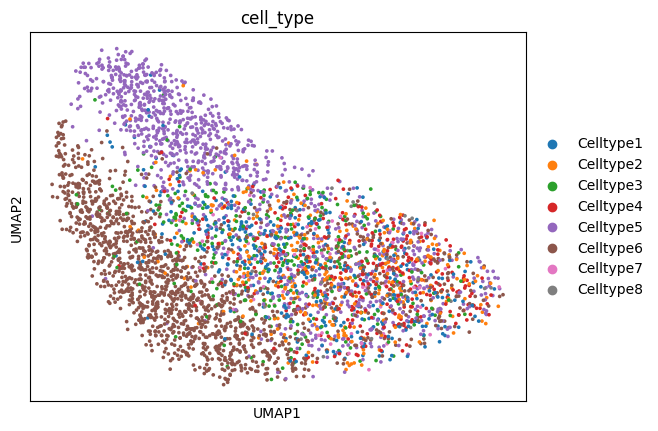

In [116]:
sc.pp.neighbors(adata, n_neighbors=5, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')